# Cascade Machine Learning for Solar Water Heater Research

This notebook shows how to build a two-stage machine learning system for a solar water heater dataset.

Stage 1 predicts the outlet temperature `Tout`. Stage 2 uses that temperature prediction to help predict the water outlet signal `Wout`.

The notebook is written like a guided research walkthrough so a student can follow the full workflow from data cleaning to model tuning, evaluation, residual analysis, and paper-ready output.

## What This Notebook Does

The workflow is split into simple steps:

1. Load and clean the raw solar water heater data.
2. Create a first model to predict outlet temperature `Tout`.
3. Use the predicted `Tout` as an input to the second model for `Wout`.
4. Tune both models with grid search and 5-fold cross-validation.
5. Report RMSE, MAE, R2, and adjusted R2 for the training folds and hold-out test set.
6. Check residual plots to see where the models make mistakes.
7. Save figures, tables, and a short written summary for manuscript use.

The main idea is that each stage helps the next one. That is why this is called a cascade model.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display

from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_predict, cross_validate, train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'legend.fontsize': 10,
    'font.size': 11,
})

RANDOM_STATE = 42
DATA_PATH = Path('data') / 'Thermosyphone_mode_60_degree.csv'
FIGURE_DIR = Path('image') / 'swh_ml_f3'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
RENAME_MAP = {
    'time': 'time',
    'mode': 'mode',
    'I [W/m2]': 'irradiance_w_m2',
    'C': 'c',
    'f': 'f',
    'ha': 'ha',
    'v': 'v',
    'Kb': 'kb',
    'Xb': 'xb',
    'Ae': 'ae',
    'Ac': 'ac',
    'beta [degree]': 'beta_deg',
    'N': 'n',
    'm_dot [kg/sec]': 'mass_flow_kg_s',
    'Cp': 'cp',
    'Tau': 'tau',
    'alpha': 'alpha',
    'Ta [C]': 'ambient_c',
    'Ta [K]': 'ambient_k',
    'Tin [C]': 'tin_c',
    'Tin [K]': 'tin_k',
    'Tout [C]': 'tout_c',
    'Tout [K]': 'tout_k',
    'Tplate [C]': 'plate_c',
    'Tplate [K]': 'plate_k',
    'Ub [W/m2 K]': 'ub_w_m2k',
    'Ue [W/m2 K]': 'ue_w_m2k',
    'Fr': 'fr',
    'effi_thermosy': 'effi_thermosy',
    'effi_forced': 'effi_forced',
    'Ttank  [C]': 'tank_c',
    'Pin [Kpa]': 'pin_kpa',
    'Pout  [Kpa]': 'pout_kpa',
}

def load_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=';')
    df.columns = [column.strip() for column in df.columns]
    df = df.rename(columns=RENAME_MAP)
    df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S', errors='coerce')
    for column in df.columns:
        if column not in {'time', 'mode'}:
            df[column] = pd.to_numeric(df[column], errors='coerce')
    df = df.dropna(subset=['time']).sort_values('time').reset_index(drop=True)
    numeric_columns = df.select_dtypes(include='number').columns
    df[numeric_columns] = df[numeric_columns].interpolate(method='linear', limit_direction='both')
    df[numeric_columns] = df[numeric_columns].ffill().bfill()
    df['time_minutes'] = (df['time'].dt.hour * 60) + df['time'].dt.minute + (df['time'].dt.second / 60.0)
    df['water_liters_step'] = df['mass_flow_kg_s'] * 600.0
    df['water_liters_cum'] = df['water_liters_step'].cumsum()
    return df

df = load_dataset(DATA_PATH)
df.head()

,time,mode,irradiance_w_m2,c,f,ha,v,kb,xb,ae,ac,beta_deg,n,mass_flow_kg_s,cp,tau,alpha,ambient_c,ambient_k,tin_c,tin_k,tout_c,tout_k,plate_c,plate_k,ub_w_m2k,ue_w_m2k,fr,effi_thermosy,effi_forced,tank_c,pin_kpa,pout_kpa,time_minutes,water_liters_step,water_liters_cum
0,1900-01-01 10:50:00,Thermosyphone,450,342.760484,1.456349,9.5,1,0.04,0.05,0.6,1,60,1,0.0,4180,0.85,0.96,34.50,307.50,30.8,303.95,31.2,304.35,32.4,305.55,0.8,0.48,0.0,0.0,0.4272,37.5,108.1,103.3,650.0,0.0,0.0
1,1900-01-01 11:00:00,Thermosyphone,450,342.760484,1.456349,9.5,1,0.04,0.05,0.6,1,60,1,0.0,4180,0.85,0.96,35.26,308.26,37.6,310.75,63.3,336.45,77.9,351.05,0.8,0.48,0.0,0.0,0.4207,37.5,108.1,103.3,660.0,0.0,0.0
2,1900-01-01 11:10:00,Thermosyphone,450,342.760484,1.456349,9.5,1,0.04,0.05,0.6,1,60,1,0.0,4180,0.85,0.96,35.20,308.20,37.6,310.75,64.3,337.45,78.1,351.25,0.8,0.48,0.0,0.0,0.4142,37.7,108.2,103.3,670.0,0.0,0.0
3,1900-01-01 11:20:00,Thermosyphone,450,342.760484,1.456349,9.5,1,0.04,0.05,0.6,1,60,1,0.0,4180,0.85,0.96,35.40,308.40,37.7,310.85,63.7,336.85,77.8,350.95,0.8,0.48,0.0,0.0,0.4077,37.7,108.1,103.1,680.0,0.0,0.0
4,1900-01-01 11:30:00,Thermosyphone,450,342.760484,1.456349,9.5,1,0.04,0.05,0.6,1,60,1,0.0,4180,0.85,0.96,35.40,308.40,37.7,310.85,63.7,336.85,77.6,350.75,0.8,0.48,0.0,0.0,0.4012,37.8,108.1,103.3,690.0,0.0,0.0


In [3]:
dataset_summary = pd.DataFrame({
    'metric': [
        'rows',
        'original_columns',
        'modeling_columns',
        'missing_values_after_cleaning',
        'Tout mean',
        'Tout std',
        'Wout mean',
        'Wout std',
    ],
    'value': [
        len(df),
        len(RENAME_MAP),
        df.shape[1],
        int(df.isna().sum().sum()),
        float(df['tout_c'].mean()),
        float(df['tout_c'].std()),
        float(df['water_liters_cum'].mean()),
        float(df['water_liters_cum'].std()),
    ]
})

display(dataset_summary)
display(df[['time', 'time_minutes', 'irradiance_w_m2', 'mass_flow_kg_s', 'tout_c', 'water_liters_cum']].head())

,metric,value
0,rows,38.000000
1,original_columns,33.000000
2,modeling_columns,36.000000
3,missing_values_after_cleaning,0.000000
4,Tout mean,70.594737
5,Tout std,8.554529
6,Wout mean,1.876863
7,Wout std,1.917499


,time,time_minutes,irradiance_w_m2,mass_flow_kg_s,tout_c,water_liters_cum
0,1900-01-01 10:50:00,650.0,450,0.0,31.2,0.0
1,1900-01-01 11:00:00,660.0,450,0.0,63.3,0.0
2,1900-01-01 11:10:00,670.0,450,0.0,64.3,0.0
3,1900-01-01 11:20:00,680.0,450,0.0,63.7,0.0
4,1900-01-01 11:30:00,690.0,450,0.0,63.7,0.0


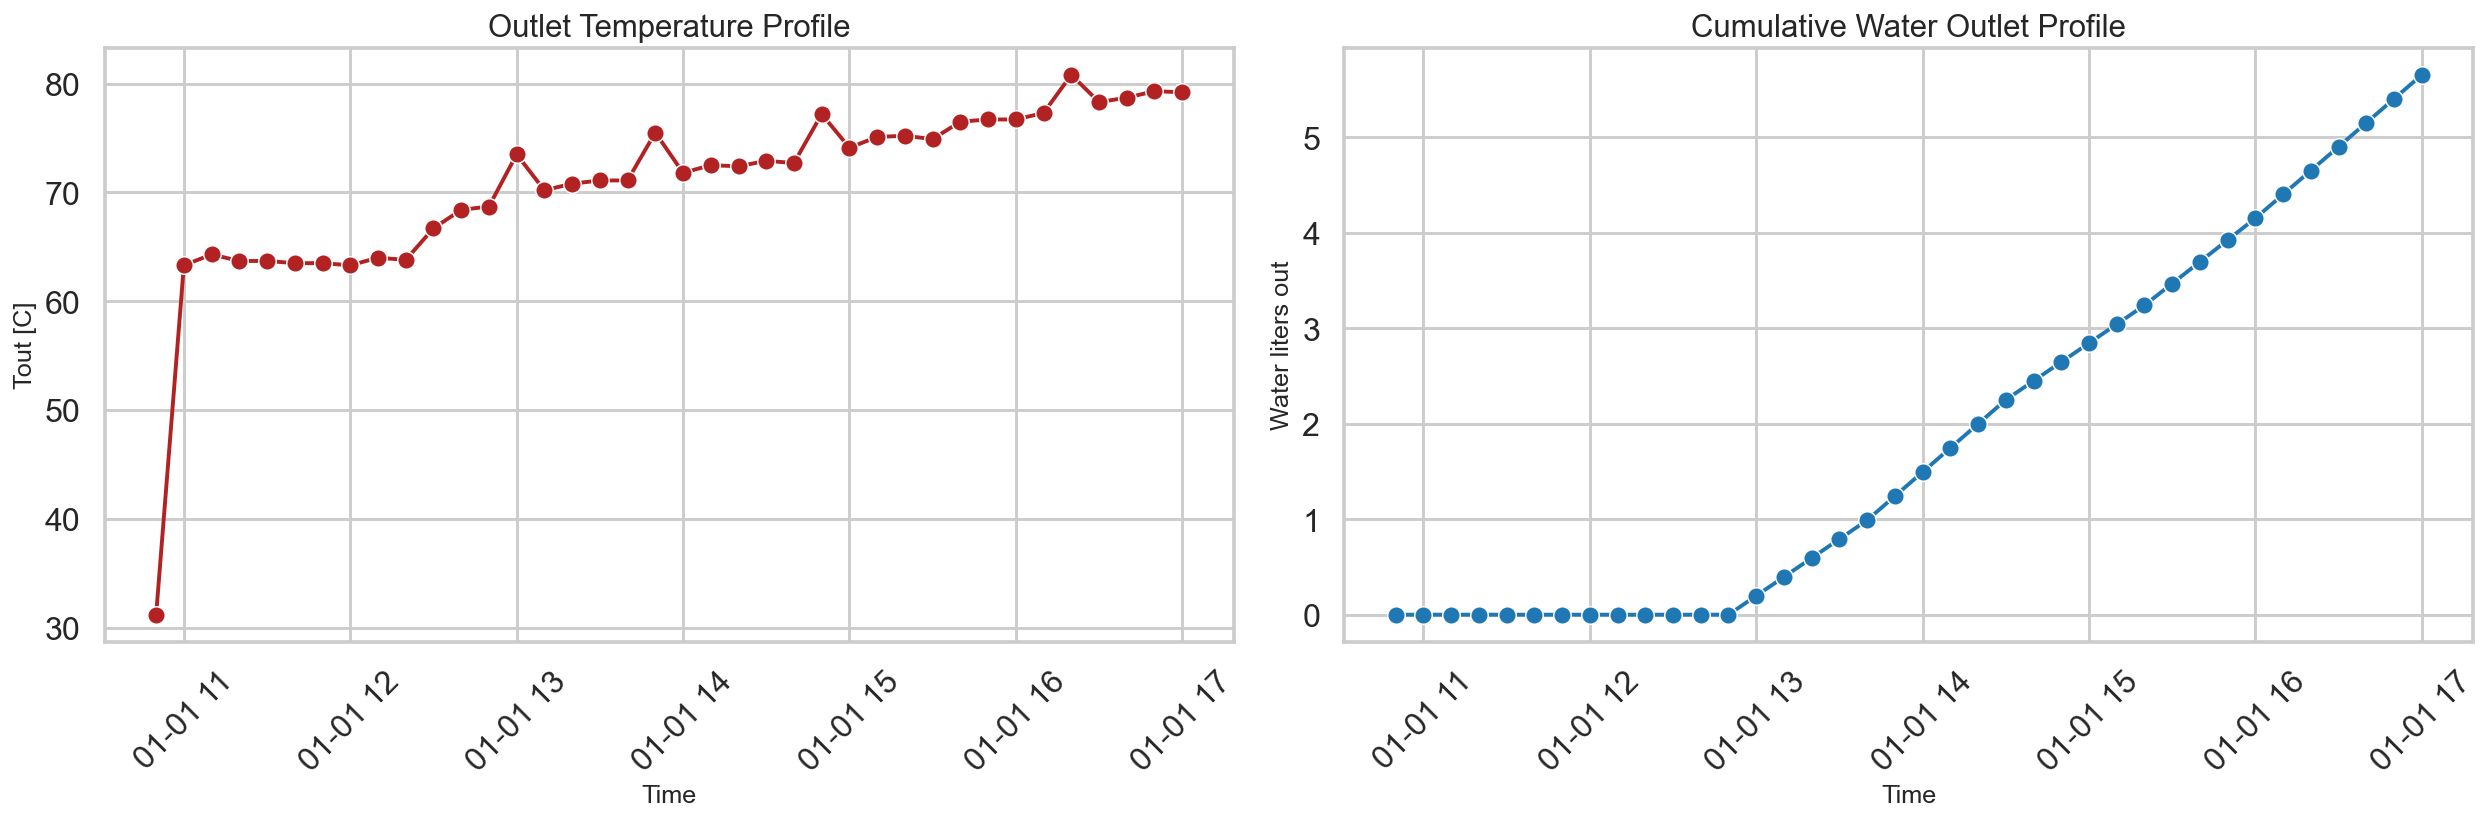

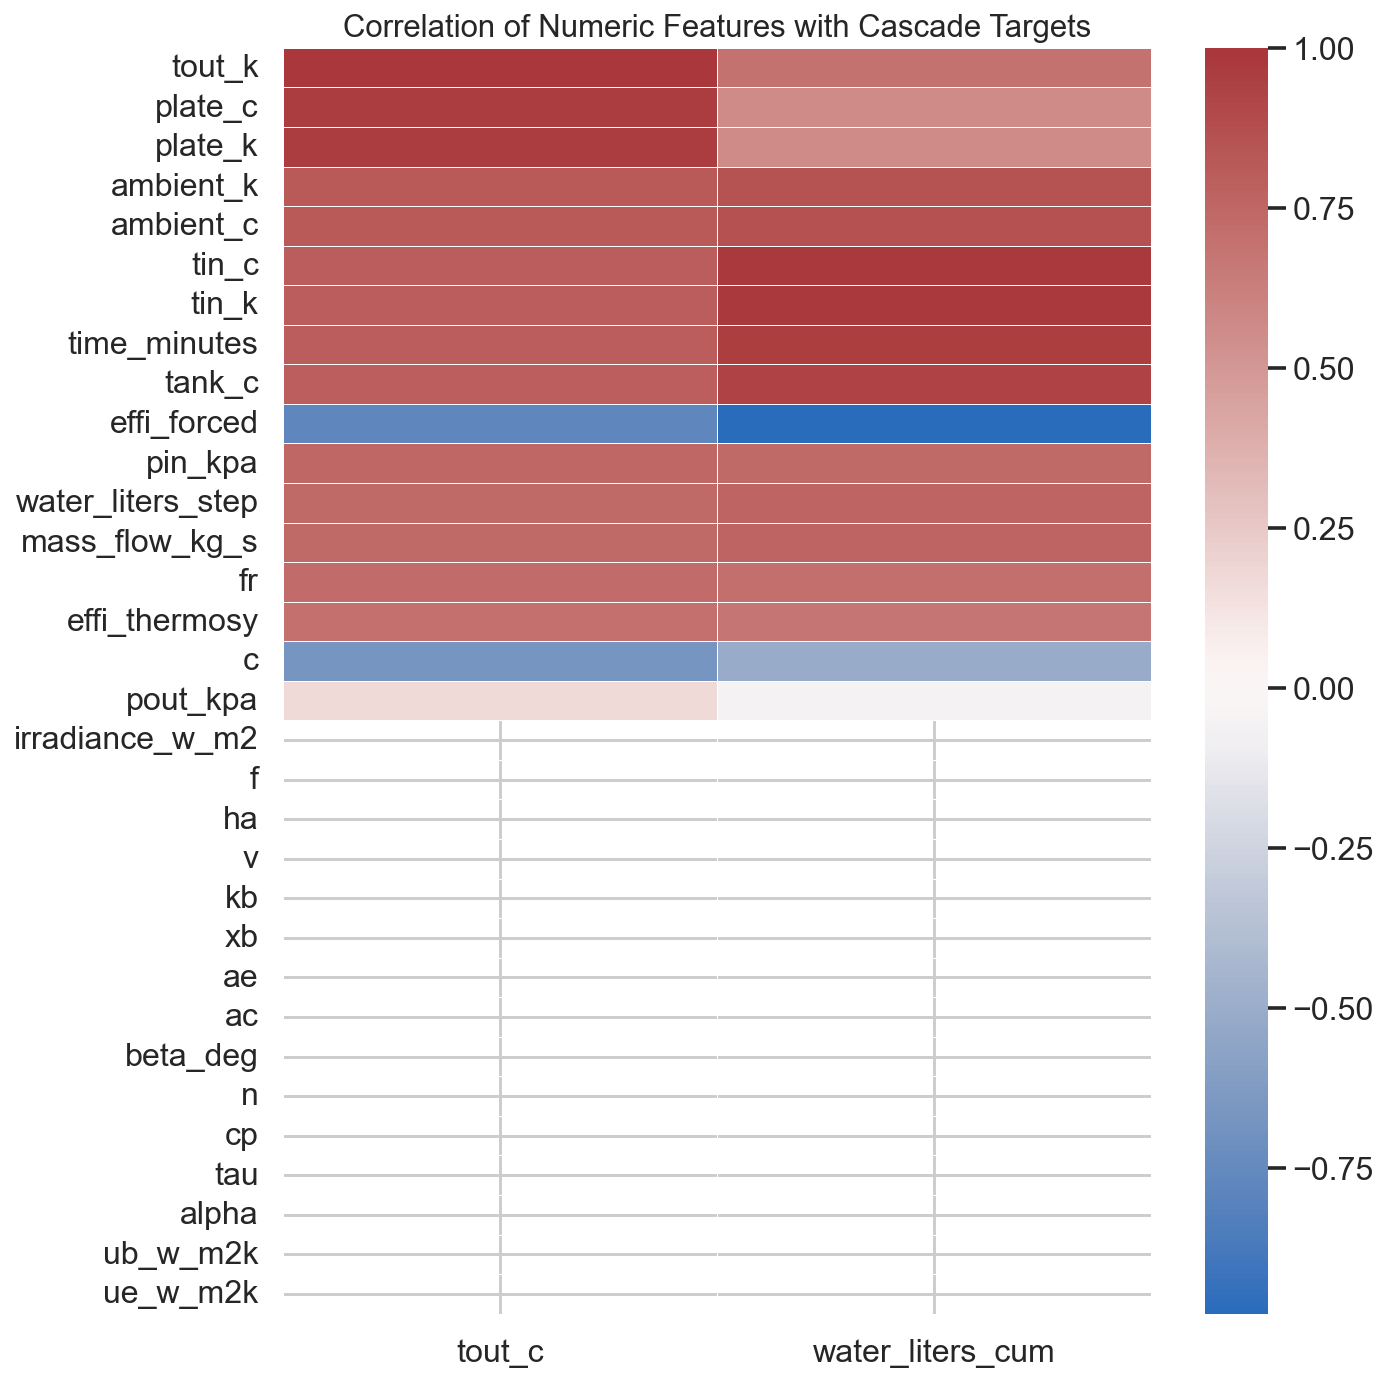

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(data=df, x='time', y='tout_c', marker='o', ax=axes[0], color='#b22222', linewidth=2)
axes[0].set_title('Outlet Temperature Profile')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Tout [C]')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=df, x='time', y='water_liters_cum', marker='o', ax=axes[1], color='#1f77b4', linewidth=2)
axes[1].set_title('Cumulative Water Outlet Profile')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Water liters out')
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()
fig.savefig(FIGURE_DIR / 'target_profiles.png', bbox_inches='tight')
plt.show()

numeric_corr = df.select_dtypes(include='number').corr(numeric_only=True)
target_corr = numeric_corr[['tout_c', 'water_liters_cum']].drop(index=['tout_c', 'water_liters_cum']).sort_values(by='tout_c', key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(10, 10))
sns.heatmap(target_corr, cmap='vlag', center=0, annot=False, linewidths=0.3)
plt.title('Correlation of Numeric Features with Cascade Targets')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'target_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [5]:
def adjusted_r2_score(y_true, y_pred, n_features):
    n_samples = len(y_true)
    r2 = r2_score(y_true, y_pred)
    if n_samples <= n_features + 1:
        return np.nan
    return 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)

def regression_metrics(y_true, y_pred, n_features):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    adj_r2 = float(adjusted_r2_score(y_true, y_pred, n_features))
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'adj_r2': adj_r2}

def dynamic_feature_selection(frame, target, threshold=0.15, top_n=8, min_features=4, forbidden=None):
    forbidden = set(forbidden or [])
    numeric = frame.select_dtypes(include='number').copy()
    corr = numeric.corr(numeric_only=True)[target].drop(labels=[target], errors='ignore').abs().sort_values(ascending=False)
    selected = corr[corr >= threshold].index.tolist()
    if len(selected) < min_features:
        selected = corr.head(top_n).index.tolist()
    selected = [column for column in selected if column not in forbidden][:top_n]
    if len(selected) < min_features:
        selected = [column for column in corr.index if column not in forbidden][:top_n]
    return selected, corr

def make_cv():
    return KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def candidate_families():
    return {
        'RandomForest': {
            'estimator': RandomForestRegressor(random_state=RANDOM_STATE),
            'param_grid': {
                'n_estimators': [200, 400],
                'max_depth': [None, 4, 8],
                'min_samples_split': [2, 4],
                'min_samples_leaf': [1, 2],
            },
        },
        'AdaBoost': {
            'estimator': AdaBoostRegressor(random_state=RANDOM_STATE),
            'param_grid': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.05, 0.1],
                'loss': ['linear', 'square'],
            },
        },
    }

def tune_model_families(X_train, y_train, cv):
    family_rows = []
    fitted_searches = {}
    for family_name, family_spec in candidate_families().items():
        search = GridSearchCV(
            estimator=family_spec['estimator'],
            param_grid=family_spec['param_grid'],
            scoring='neg_root_mean_squared_error',
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_train, y_train)
        best_estimator = search.best_estimator_
        oof_pred = cross_val_predict(best_estimator, X_train, y_train, cv=cv, n_jobs=-1)
        row = regression_metrics(y_train, oof_pred, X_train.shape[1])
        row.update({
            'family': family_name,
            'best_params': search.best_params_,
        })
        family_rows.append(row)
        fitted_searches[family_name] = search
    results = pd.DataFrame(family_rows).sort_values('rmse').reset_index(drop=True)
    best_family = results.loc[0, 'family']
    return results, fitted_searches[best_family], fitted_searches

def test_metrics_from_estimator(estimator, X_test, y_test):
    prediction = estimator.predict(X_test)
    return prediction, regression_metrics(y_test, prediction, X_test.shape[1])

def plot_actual_vs_predicted(y_true, y_pred, title, filename):
    fig, ax = plt.subplots(figsize=(7.5, 7.5))
    sns.scatterplot(x=y_true, y=y_pred, ax=ax, s=80, color='#2c7fb8', edgecolor='white', linewidth=0.6)
    limits = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(limits, limits, '--', color='#b22222', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Observed')
    ax.set_ylabel('Predicted')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, bbox_inches='tight')
    plt.show()

def plot_residual_diagnostics(y_true, y_pred, title_prefix, filename_prefix):
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    sns.scatterplot(x=y_pred, y=residuals, ax=axes[0], s=70, color='#4c78a8', edgecolor='white', linewidth=0.4)
    axes[0].axhline(0, color='#b22222', linestyle='--', linewidth=2)
    axes[0].set_title(f'{title_prefix}: Residuals vs Predicted')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Residual')
    sns.histplot(residuals, kde=True, ax=axes[1], color='#f58518', bins=min(12, len(residuals)))
    axes[1].axvline(0, color='#b22222', linestyle='--', linewidth=2)
    axes[1].set_title(f'{title_prefix}: Residual Distribution')
    axes[1].set_xlabel('Residual')
    axes[1].set_ylabel('Count')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f'{filename_prefix}_residuals.png', bbox_inches='tight')
    plt.show()

def model_summary_table(result_frames):
    table = pd.concat(result_frames, ignore_index=True)
    columns = ['scenario', 'family', 'rmse', 'mae', 'r2', 'adj_r2', 'best_params']
    return table[columns].sort_values(['scenario', 'rmse']).reset_index(drop=True)

## Train-Test Protocol and Dynamic Feature Selection

The hold-out split is created once and reused for both direct and cascade comparisons. All feature selection is computed from the training fold only to avoid leakage.

For publication reporting, the notebook prints the final train/test sizes, the selected feature sets for `Tout` and `Wout`, and the correlation scores that justify the feature choice.

In [6]:
train_df, test_df = train_test_split(df, test_size=0.25, random_state=RANDOM_STATE, shuffle=True)
cv = make_cv()

stage1_forbidden = ['tout_c', 'tout_k', 'water_liters_step', 'water_liters_cum']
stage1_features, stage1_corr = dynamic_feature_selection(train_df, 'tout_c', threshold=0.15, top_n=6, min_features=4, forbidden=stage1_forbidden)

print(f'Total samples: {len(df)}')
print(f'Train samples: {len(train_df)}')
print(f'Test samples: {len(test_df)}')
print('Stage 1 Tout features:', stage1_features)

display(pd.DataFrame({'Tout correlation': stage1_corr.loc[stage1_features]}))

Total samples: 38
Train samples: 28
Test samples: 10
Stage 1 Tout features: ['plate_c', 'plate_k', 'ambient_k', 'ambient_c', 'tin_k', 'tin_c']


,Tout correlation
plate_c,0.973250
plate_k,0.973250
ambient_k,0.812963
ambient_c,0.811020
tin_k,0.795853
tin_c,0.795853


## Stage 1: Cross-Validated and Tuned `Tout` Modeling

This stage is the foundation of the cascade. The notebook tunes several regression families with grid search, evaluates them with five-fold cross-validation, and chooses the best-performing family by cross-validated RMSE.

The held-out test set is used only after tuning to provide an unbiased final estimate for the temperature model.

In [7]:
X_train_stage1 = train_df[stage1_features].copy()
y_train_stage1 = train_df['tout_c'].copy()
X_test_stage1 = test_df[stage1_features].copy()
y_test_stage1 = test_df['tout_c'].copy()

stage1_cv_results, stage1_best_search, stage1_all_searches = tune_model_families(X_train_stage1, y_train_stage1, cv)
stage1_best_estimator = stage1_best_search.best_estimator_
stage1_train_oof_pred = cross_val_predict(stage1_best_estimator, X_train_stage1, y_train_stage1, cv=cv, n_jobs=-1)
stage1_test_pred = stage1_best_estimator.predict(X_test_stage1)

stage1_oof_metrics = regression_metrics(y_train_stage1, stage1_train_oof_pred, X_train_stage1.shape[1])
stage1_test_metrics = regression_metrics(y_test_stage1, stage1_test_pred, X_test_stage1.shape[1])

display(stage1_cv_results)
display(pd.DataFrame([
    {'split': 'train_oof', **stage1_oof_metrics},
    {'split': 'test_holdout', **stage1_test_metrics},
]))

,rmse,mae,r2,adj_r2,family,best_params
0,6.217905,2.008217,0.522505,0.386078,AdaBoost,"{'learning_rate': 0.01, 'loss': 'linear', 'n_e..."
1,6.268883,2.106032,0.514644,0.375971,RandomForest,"{'max_depth': 4, 'min_samples_leaf': 1, 'min_s..."


,split,rmse,mae,r2,adj_r2
0,train_oof,6.217905,2.008217,0.522505,0.386078
1,test_holdout,2.123014,1.579099,0.858963,0.576890


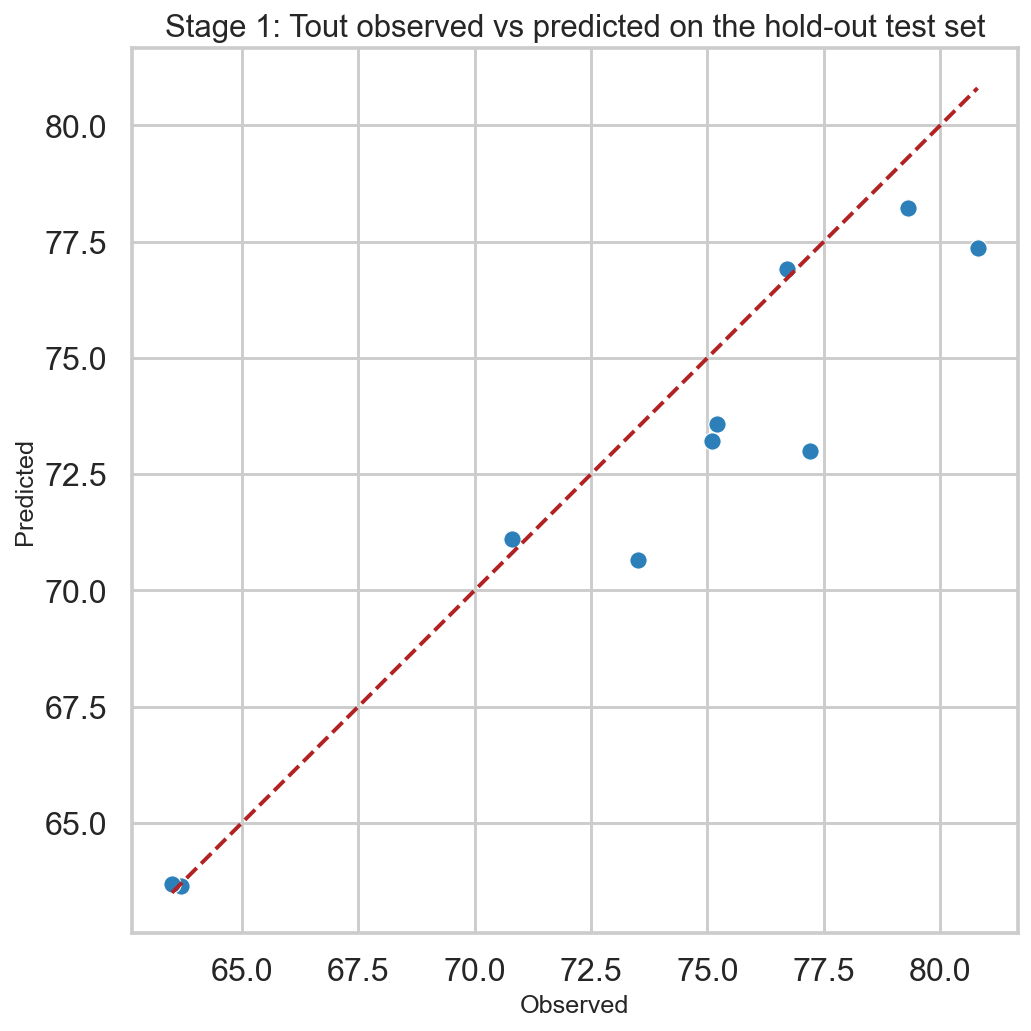

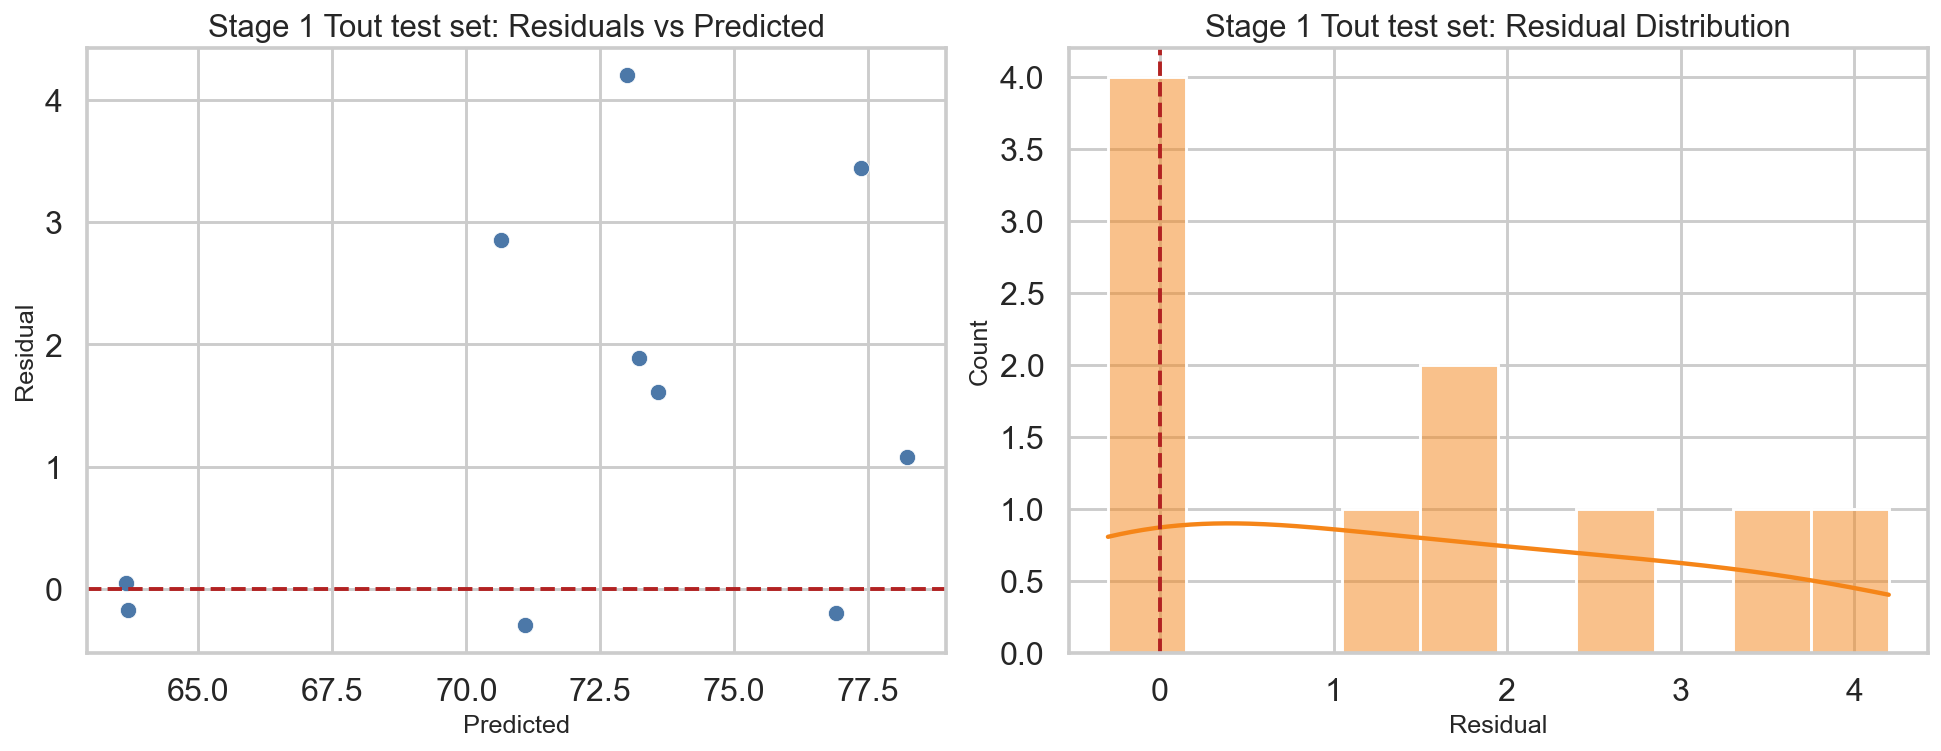

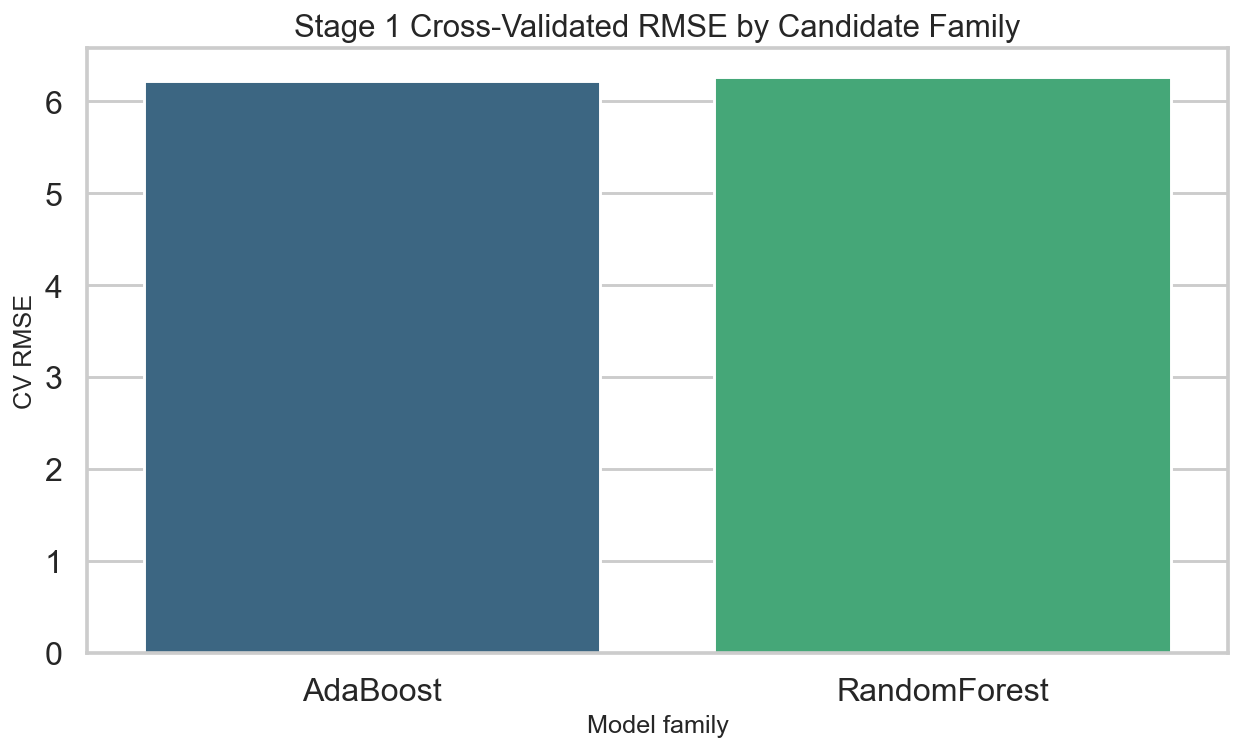

In [8]:
plot_actual_vs_predicted(y_test_stage1, stage1_test_pred, 'Stage 1: Tout observed vs predicted on the hold-out test set', 'stage1_tout_actual_vs_pred')
plot_residual_diagnostics(y_test_stage1, stage1_test_pred, 'Stage 1 Tout test set', 'stage1_tout_test')

plt.figure(figsize=(9, 5.5))
sns.barplot(data=stage1_cv_results, x='family', y='rmse', palette='viridis')
plt.title('Stage 1 Cross-Validated RMSE by Candidate Family')
plt.xlabel('Model family')
plt.ylabel('CV RMSE')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'stage1_cv_rmse_comparison.png', bbox_inches='tight')
plt.show()

## Cascade Stage 2: Water Outlet Modeling

The cascade stage uses predicted `Tout` rather than observed `Tout` when fitting the water outlet model. To prevent leakage, the notebook uses out-of-fold `Tout` predictions on the training set and full-train predictions on the hold-out set.

This section is intentionally limited to the cascade pipeline so the paper can focus on the staged-learning mechanism rather than a direct-baseline comparison.

In [9]:
train_cascade_df = train_df.copy()
test_cascade_df = test_df.copy()
train_cascade_df['tout_pred'] = stage1_train_oof_pred
test_cascade_df['tout_pred'] = stage1_test_pred

cascade_forbidden = ['tout_c', 'tout_k', 'water_liters_step', 'water_liters_cum']
cascade_features, cascade_corr = dynamic_feature_selection(train_cascade_df, 'water_liters_cum', threshold=0.15, top_n=6, min_features=4, forbidden=cascade_forbidden)

X_train_cascade = train_cascade_df[cascade_features].copy()
y_train_cascade = train_cascade_df['water_liters_cum'].copy()
X_test_cascade = test_cascade_df[cascade_features].copy()
y_test_cascade = test_cascade_df['water_liters_cum'].copy()

print('Cascade features:', cascade_features)

Cascade features: ['effi_forced', 'tin_k', 'tin_c', 'time_minutes', 'tank_c', 'tout_pred']


In [10]:
stage2_cv_results, stage2_best_search, _ = tune_model_families(X_train_cascade, y_train_cascade, cv)
stage2_best_estimator = stage2_best_search.best_estimator_

stage2_train_oof_pred = cross_val_predict(stage2_best_estimator, X_train_cascade, y_train_cascade, cv=cv, n_jobs=-1)
stage2_test_pred = stage2_best_estimator.predict(X_test_cascade)

stage2_oof_metrics = regression_metrics(y_train_cascade, stage2_train_oof_pred, X_train_cascade.shape[1])
stage2_test_metrics = regression_metrics(y_test_cascade, stage2_test_pred, X_test_cascade.shape[1])

stage2_results_table = pd.DataFrame([
    {'split': 'train_oof', **stage2_oof_metrics},
    {'split': 'test_holdout', **stage2_test_metrics},
])
display(stage2_cv_results)
display(stage2_results_table)

,rmse,mae,r2,adj_r2,family,best_params
0,0.193838,0.114626,0.988988,0.985842,RandomForest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
1,0.221001,0.167421,0.985686,0.981596,AdaBoost,"{'learning_rate': 0.1, 'loss': 'square', 'n_es..."


,split,rmse,mae,r2,adj_r2
0,train_oof,0.193838,0.114626,0.988988,0.985842
1,test_holdout,0.060610,0.041293,0.999013,0.997038


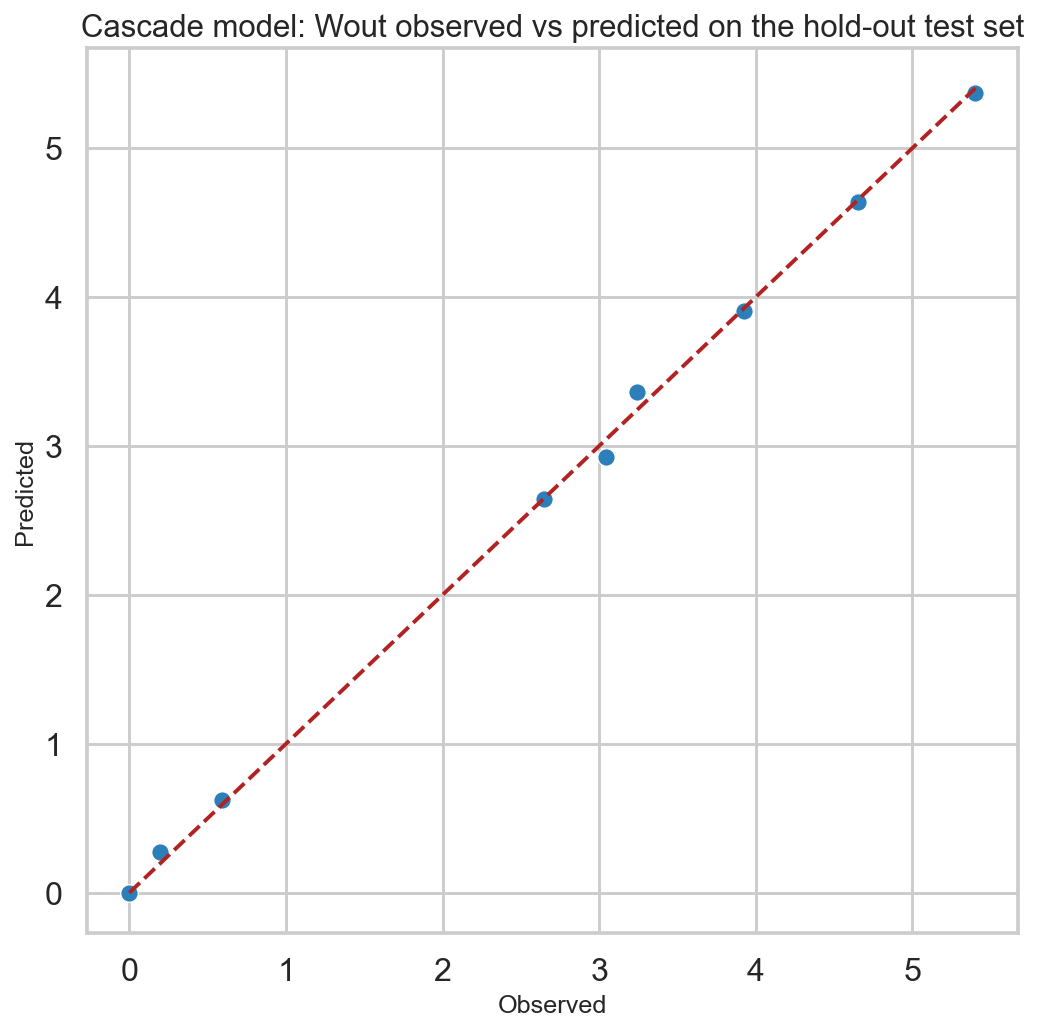

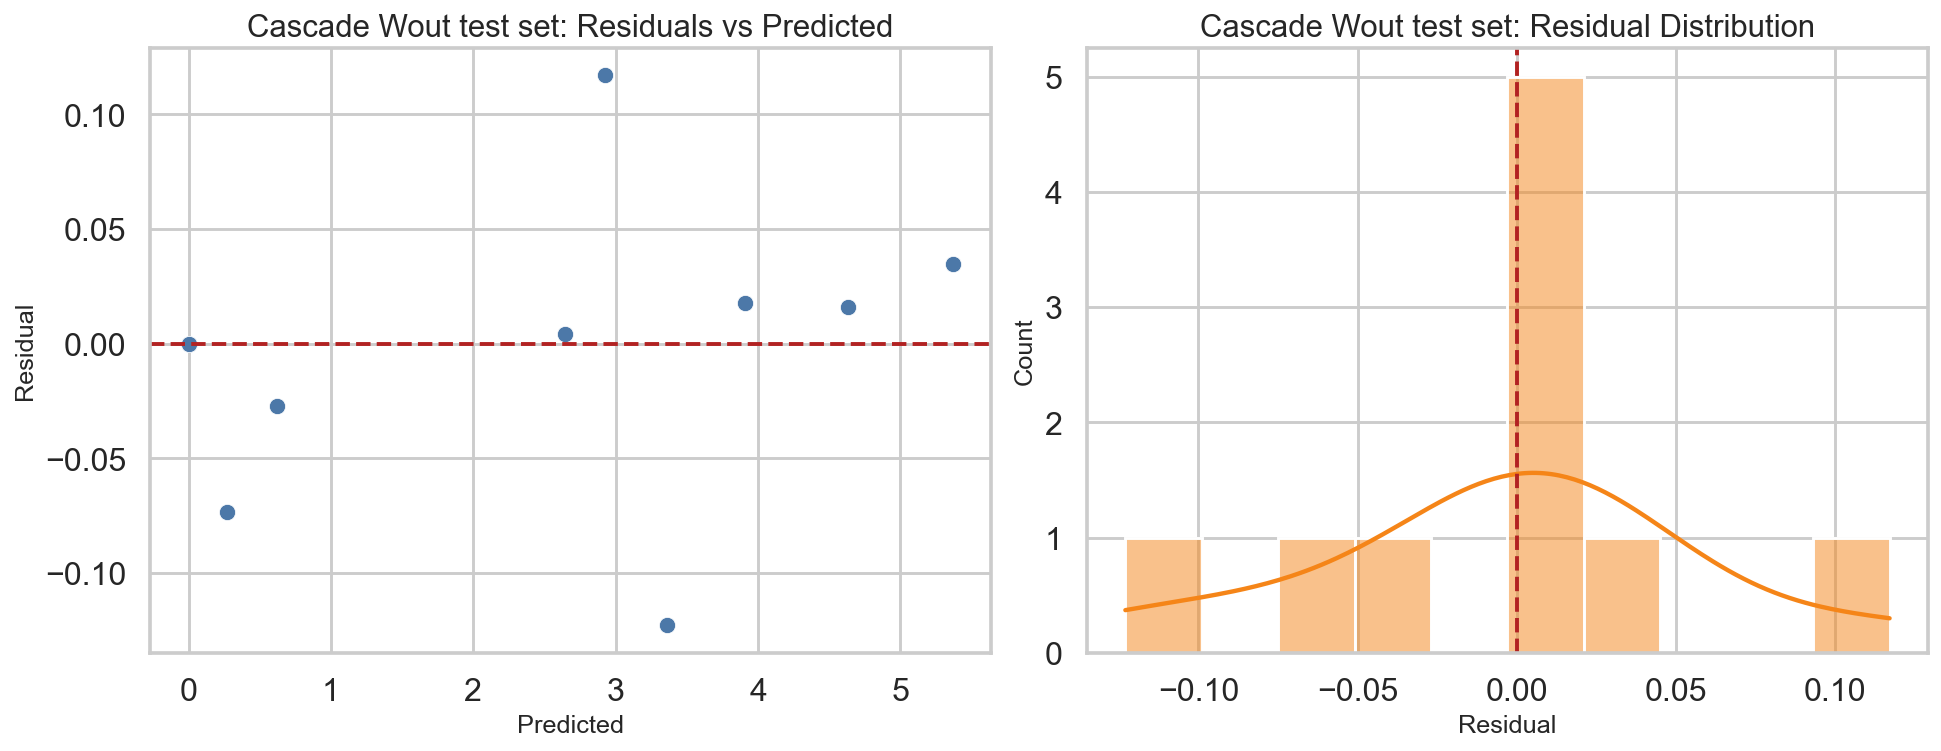

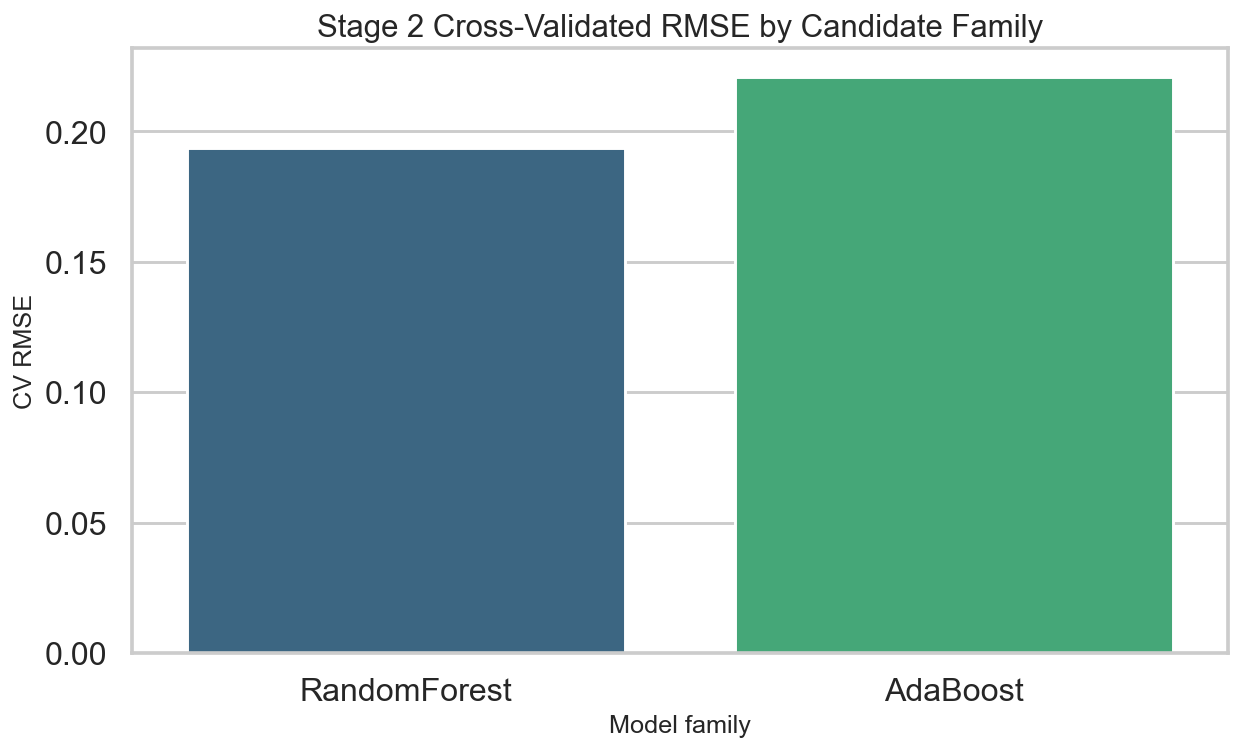

In [11]:
plot_actual_vs_predicted(y_test_cascade, stage2_test_pred, 'Cascade model: Wout observed vs predicted on the hold-out test set', 'cascade_wout_actual_vs_pred')
plot_residual_diagnostics(y_test_cascade, stage2_test_pred, 'Cascade Wout test set', 'cascade_wout_test')

plt.figure(figsize=(9, 5.5))
sns.barplot(data=stage2_cv_results, x='family', y='rmse', palette='viridis')
plt.title('Stage 2 Cross-Validated RMSE by Candidate Family')
plt.xlabel('Model family')
plt.ylabel('CV RMSE')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'stage2_cv_rmse_comparison.png', bbox_inches='tight')
plt.show()

,correlation_with_stage1_error
cascade_stage2_abs_error,0.15442


tout_abs_error                 cascade_wout_abs_error                
                         mean    median count                   mean    median count
error_bin                                                                           
(0.049, 0.225]       0.142593  0.177778     3               0.005936  0.000000     3
(0.225, 1.344]       0.687500  0.687500     2               0.030807  0.030807     2
(1.344, 2.609]       1.749107  1.749107     2               0.119997  0.119997     2
(2.609, 4.2]         3.496667  3.440000     3               0.031172  0.015876     3

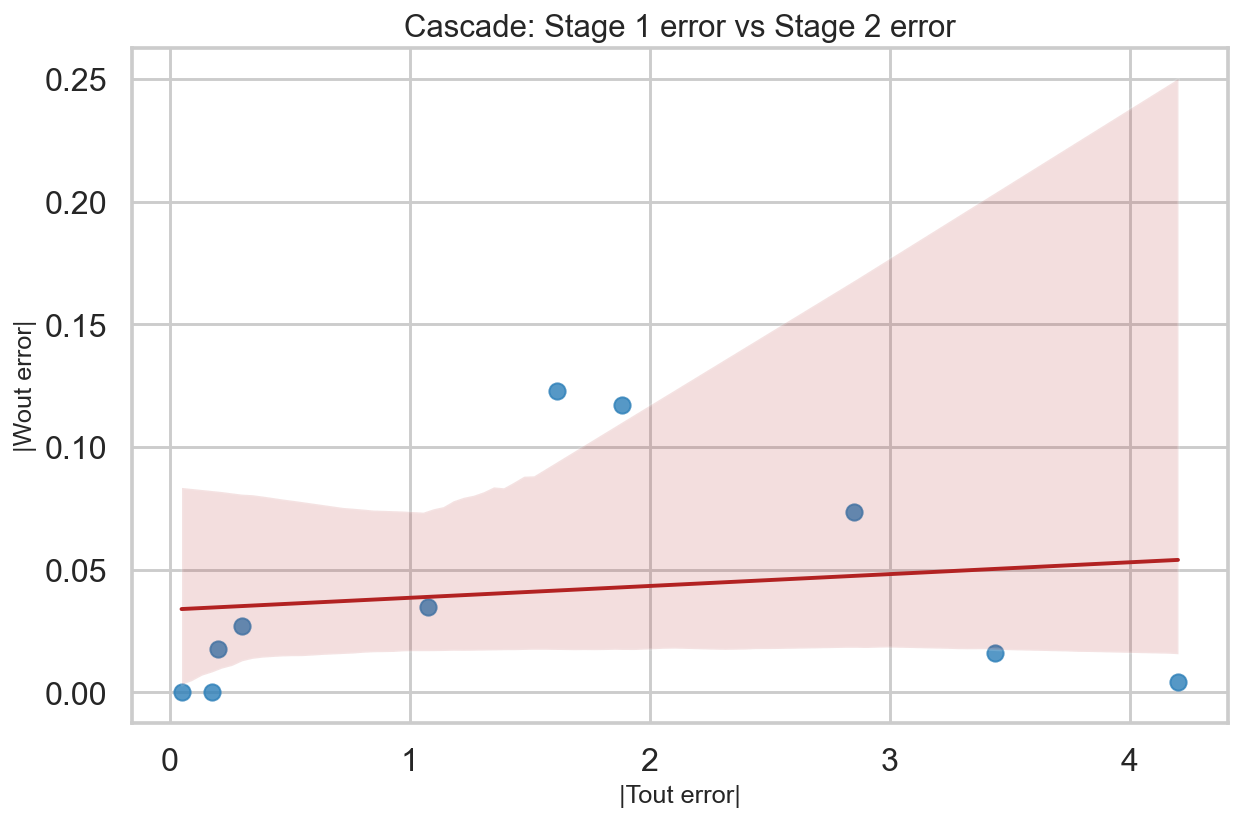

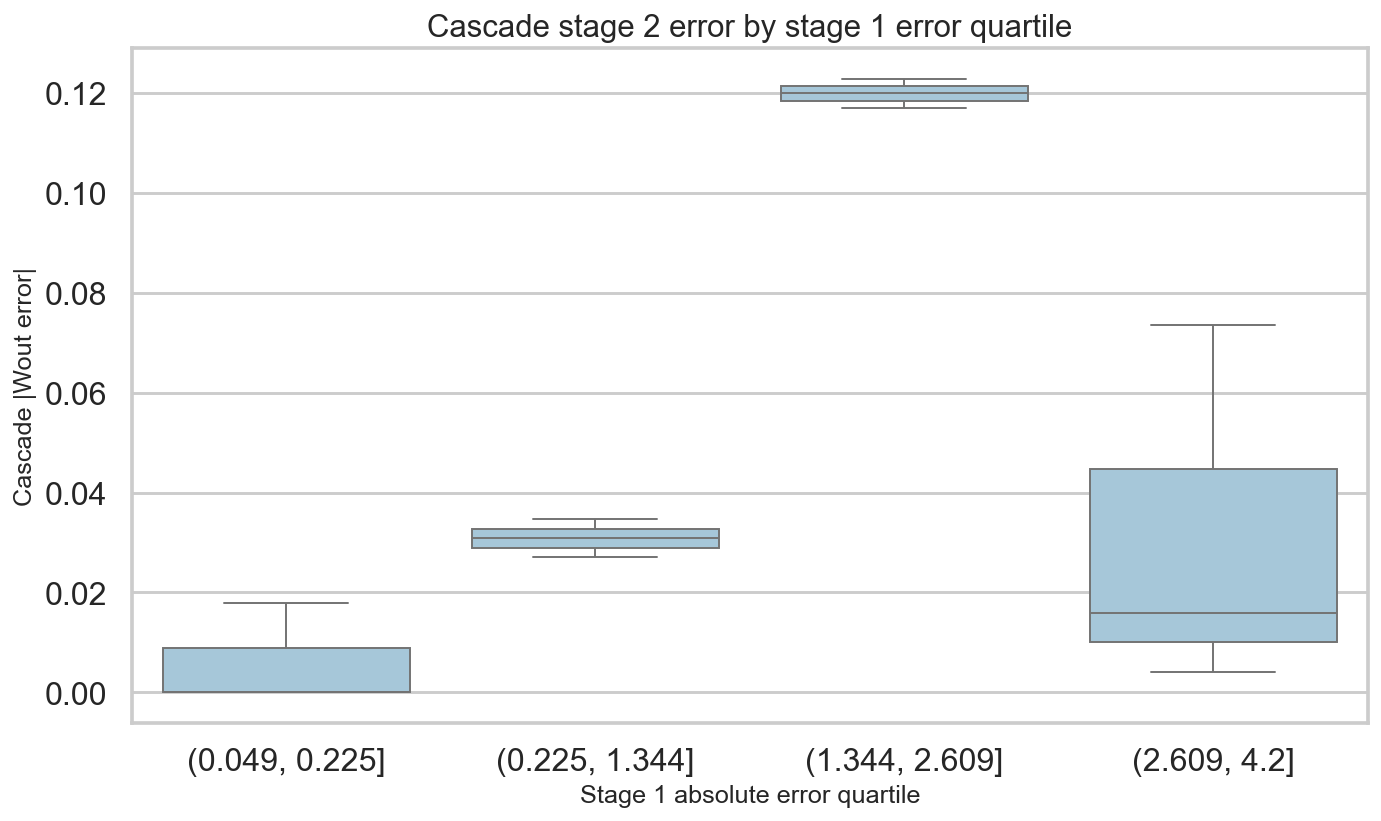


This study evaluated a cascade machine-learning pipeline for a solar water-heating dataset with 38 cleaned observations, using a 75/25 hold-out split and 5-fold cross-validation on the training fold only.

Stage 1 predicted outlet temperature (Tout) using a tuned AdaBoost model, with hold-out RMSE 2.1230, MAE 1.5791, R2 0.8590, and adjusted R2 0.5769.

Stage 2 used the predicted Tout signal as an additional feature for water-outlet prediction and selected a tuned RandomForest model, achieving hold-out RMSE 0.0606, MAE 0.0413, R2 0.9990, and adjusted R2 0.9970.

Residual diagnostics were used to inspect bias and dispersion, and the stage-1-to-stage-2 error correlation was 0.1544, indicating how first-stage prediction error propagated through the cascade.

Dynamic correlation-based feature selection was applied inside the training fold to keep the workflow leakage-safe and reproducible.


Exported manuscript assets to manuscript_assets/swh_ml_f3


In [12]:
propagation_df = pd.DataFrame({
    'tout_abs_error': np.abs(y_test_stage1.reset_index(drop=True) - pd.Series(stage1_test_pred).reset_index(drop=True)),
    'cascade_wout_abs_error': np.abs(y_test_cascade.reset_index(drop=True) - pd.Series(stage2_test_pred).reset_index(drop=True)),
})

cascade_error_corr = propagation_df['tout_abs_error'].corr(propagation_df['cascade_wout_abs_error'])
propagation_df['error_bin'] = pd.qcut(propagation_df['tout_abs_error'], q=min(4, len(propagation_df)), duplicates='drop')
propagation_summary = propagation_df.groupby('error_bin', observed=False).agg(['mean', 'median', 'count'])

display(pd.DataFrame({
    'correlation_with_stage1_error': [cascade_error_corr],
}, index=['cascade_stage2_abs_error']))
display(propagation_summary)

fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=propagation_df, x='tout_abs_error', y='cascade_wout_abs_error', ax=ax, scatter_kws={'s': 70, 'color': '#2c7fb8'}, line_kws={'color': '#b22222', 'linewidth': 2})
ax.set_title('Cascade: Stage 1 error vs Stage 2 error')
ax.set_xlabel('|Tout error|')
ax.set_ylabel('|Wout error|')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'error_propagation_scatter.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=propagation_df, x='error_bin', y='cascade_wout_abs_error', ax=ax, color='#9ecae1')
ax.set_title('Cascade stage 2 error by stage 1 error quartile')
ax.set_xlabel('Stage 1 absolute error quartile')
ax.set_ylabel('Cascade |Wout error|')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'cascade_error_by_stage1_quartile.png', bbox_inches='tight')
plt.show()

stage1_best_family = stage1_cv_results.iloc[0]['family']
stage2_best_family = stage2_cv_results.iloc[0]['family']

paper_summary = f"""
This study evaluated a cascade machine-learning pipeline for a solar water-heating dataset with {len(df)} cleaned observations, using a 75/25 hold-out split and 5-fold cross-validation on the training fold only.

Stage 1 predicted outlet temperature (Tout) using a tuned {stage1_best_family} model, with hold-out RMSE {stage1_test_metrics['rmse']:.4f}, MAE {stage1_test_metrics['mae']:.4f}, R2 {stage1_test_metrics['r2']:.4f}, and adjusted R2 {stage1_test_metrics['adj_r2']:.4f}.

Stage 2 used the predicted Tout signal as an additional feature for water-outlet prediction and selected a tuned {stage2_best_family} model, achieving hold-out RMSE {stage2_test_metrics['rmse']:.4f}, MAE {stage2_test_metrics['mae']:.4f}, R2 {stage2_test_metrics['r2']:.4f}, and adjusted R2 {stage2_test_metrics['adj_r2']:.4f}.

Residual diagnostics were used to inspect bias and dispersion, and the stage-1-to-stage-2 error correlation was {cascade_error_corr:.4f}, indicating how first-stage prediction error propagated through the cascade.

Dynamic correlation-based feature selection was applied inside the training fold to keep the workflow leakage-safe and reproducible.
"""

display(Markdown(paper_summary))

EXPORT_ROOT = Path('manuscript_assets') / 'swh_ml_f3'
FIG_EXPORT_DIR = EXPORT_ROOT / 'figures'
TABLE_EXPORT_DIR = EXPORT_ROOT / 'tables'
TEXT_EXPORT_DIR = EXPORT_ROOT / 'text'
for folder in [FIG_EXPORT_DIR, TABLE_EXPORT_DIR, TEXT_EXPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

holdout_metrics_table = pd.DataFrame([
    {'split': 'stage1_test', **stage1_test_metrics},
    {'split': 'stage2_test', **stage2_test_metrics},
])

stage1_cv_results.to_csv(TABLE_EXPORT_DIR / 'stage1_cv_results.csv', index=False)
stage2_cv_results.to_csv(TABLE_EXPORT_DIR / 'stage2_cv_results.csv', index=False)
holdout_metrics_table.to_csv(TABLE_EXPORT_DIR / 'holdout_metrics.csv', index=False)
propagation_summary.to_csv(TABLE_EXPORT_DIR / 'cascade_error_propagation_summary.csv')
(TEXT_EXPORT_DIR / 'paper_summary.md').write_text(paper_summary, encoding='utf-8')

for figure_name in [
    'target_profiles.png',
    'target_correlation_heatmap.png',
    'stage1_tout_actual_vs_pred.png',
    'stage1_tout_test_residuals.png',
    'stage1_cv_rmse_comparison.png',
    'cascade_wout_actual_vs_pred.png',
    'cascade_wout_test_residuals.png',
    'stage2_cv_rmse_comparison.png',
    'error_propagation_scatter.png',
    'cascade_error_by_stage1_quartile.png',
]:
    source_path = FIGURE_DIR / figure_name
    if source_path.exists():
        destination_path = FIG_EXPORT_DIR / figure_name
        destination_path.write_bytes(source_path.read_bytes())

print(f'Exported manuscript assets to {EXPORT_ROOT}')

## Student-Friendly Summary

### 1. Data size and split details
The cleaned dataset contains 38 observations. The notebook uses a 75/25 train-test split and 5-fold cross-validation on the training set only, so the test set stays unseen until the final evaluation.

### 2. What is being predicted
Stage 1 predicts outlet temperature `Tout`. Stage 2 predicts water outlet `Wout` using the first-stage temperature prediction as one of its inputs.

### 3. Why tuning and cross-validation matter
Grid search tries multiple hyperparameter settings. Cross-validation checks whether a model works well across different training folds instead of relying on a single lucky split.

### 4. Why the feature selection changes dynamically
The notebook chooses features from correlation scores computed on the training data. That keeps the pipeline data-driven while avoiding leakage from the test set.

### 5. How to read the metrics
RMSE gives the average size of the error in target units. MAE is the average absolute error. R2 shows how much of the variation the model explains. Adjusted R2 adds a penalty when too many features are used.

### 6. How to read the residual plots
Residuals are `observed - predicted`. If residuals are centered around zero and spread evenly, the model is behaving more reasonably. Large patterns or strong asymmetry suggest bias or unstable predictions.

### 7. What the propagation analysis means
If large `Tout` errors are followed by larger `Wout` errors, then the cascade is sensitive to the first stage. This helps explain whether prediction errors are being passed from one stage to the next.

### 8. Best place to start reading
Start with the data loading and cleaning cell, then follow the notebook in order. The final summary cell is the shortest place to get the main result, while the plots explain the behavior visually.

### 9. Suggested paper wording
Use the exported tables and figures from `manuscript_assets/swh_ml_f3` when writing the report or paper. The folder already contains the metrics tables, residual plots, and summary text.